In [1]:
# Standard library
import os
import json
import shutil
import pickle
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bars
from tqdm import tqdm
from tqdm.auto import tqdm

# Computer vision
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# Torchvision
import torchvision
from torchvision import transforms
from torchvision import models

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

# Scientific computing
from scipy.spatial.distance import euclidean

# MediaPipe
import mediapipe as mp

In [2]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

with open(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "folds.json"
) as f:
    folds = json.load(f)

print("Number of folds:", len(folds))

Number of folds: 5


In [6]:
TEST_SUBJECTS = ["01", "06", "11", "16", "21", "26", "31", "36", "41"]
windows_df = pd.read_csv(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

test_df = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
]

print("Test subjects:")
print(sorted(test_df["subject"].unique()))
print("Number of subjects:",
      len(test_df["subject"].unique()))
print("Number of windows:",
      len(test_df))

Test subjects:
['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of subjects: 9
Number of windows: 16206


In [4]:
all_dev = set()

for fold in folds:
    all_dev.update(fold["train_subjects"])
    all_dev.update(fold["val_subjects"])

print("Development subjects:", len(all_dev))
print("Overlap with test subjects:",
      sorted(all_dev & set(TEST_SUBJECTS)))

assert len(all_dev) == 38
assert len(all_dev & set(TEST_SUBJECTS)) == 0

print("✅ Test subjects are completely excluded from development folds.")

Development subjects: 38
Overlap with test subjects: []
✅ Test subjects are completely excluded from development folds.


In [48]:
for p in (PROJECT_ROOT / "processed" / "UTA" / "windows").iterdir():
    print(p)

In [2]:
from pathlib import Path

DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

for p in DATA_ROOT.iterdir():
    print(p.name)


print(len(list(DATA_ROOT.iterdir())))
print(sorted([p.name for p in DATA_ROOT.iterdir()])[:15])

Fold1_part1
Fold1_part2
Fold2_part1
Fold2_part2
Fold3_part1
Fold3_part2
Fold4_part1
Fold4_part2
8
['Fold1_part1', 'Fold1_part2', 'Fold2_part1', 'Fold2_part2', 'Fold3_part1', 'Fold3_part2', 'Fold4_part1', 'Fold4_part2']


In [3]:
from pathlib import Path

for p in (PROJECT_ROOT / "datasets").iterdir():
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\MENDELEY
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\NTHU
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA


In [4]:
for fold_dir in DATA_ROOT.iterdir():
    nested = fold_dir / fold_dir.name
    print(nested)
    print(
        sorted([
            p.name for p in nested.iterdir()
            if p.is_dir()
        ])[:10]
    )
    print()

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1
['01', '02', '03', '04', '05', '06']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2
['07', '08', '09', '10', '11', '12']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1
['13', '14', '15', '16', '17', '18']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2
['19', '20', '21', '22', '23', '24']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1
['25', '26', '27', '28', '29', '30']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2
['31', '32', '33', '34', '35', '36']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1
['37', '38', '39', '40', '41']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part2\Fold4_part2
['42', '43', '44', '45', '46', '47',

In [5]:
subject_paths = {}

for subject in TEST_SUBJECTS:

    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

for s, p in subject_paths.items():
    print(s, "->", p)

01 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01
06 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\06
11 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\11
16 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1\16
21 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2\21
26 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1\26
31 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\31
36 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\36
41 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1\41
46 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part2\Fold4_part2\46


In [6]:
subject = "01"
path = subject_paths[subject]

for p in path.rglob("*"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\0.mov
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\10.MOV
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\5.mov


In [7]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import euclidean
from tqdm import tqdm

In [8]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

TEST_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

In [9]:
windows_df = pd.read_csv(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

test_df = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
]

print("Test subjects:", sorted(test_df["subject"].unique()))
print("Number of test subjects:", len(test_df["subject"].unique()))
print("Number of test windows:", len(test_df))

Test subjects: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of test subjects: 9
Number of test windows: 16206


In [10]:
subject_paths = {}

for subject in TEST_SUBJECTS:
    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

subject_paths

{'01': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/01'),
 '06': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/06'),
 '11': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part2/Fold1_part2/11'),
 '16': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part1/Fold2_part1/16'),
 '21': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part2/Fold2_part2/21'),
 '26': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part1/Fold3_part1/26'),
 '31': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/31'),
 '36': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/36'),
 '41': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold

In [10]:
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [11]:
def eye_aspect_ratio(eye):
    A = euclidean(eye[1], eye[5])
    B = euclidean(eye[2], eye[4])
    C = euclidean(eye[0], eye[3])

    if C == 0:
        return np.nan

    return (A + B) / (2.0 * C)

In [12]:
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

In [16]:
from tqdm.auto import tqdm

ear_records = []

for subject, path in subject_paths.items():

    print(f"\n{'='*60}")
    print(f"Subject {subject}")
    print(f"{'='*60}")

    # Automatically find 0, 5 and 10 videos
    videos = []

    for stem in ["0", "5", "10"]:
        matches = list(path.glob(f"{stem}.*"))

        if len(matches) == 0:
            print(f"❌ Could not find video {stem} for subject {subject}")
            continue

        videos.append(matches[0])

    labels = {
        "0": "Alert",
        "5": "Low Vigilant",
        "10": "Drowsy"
    }

    for video_path in videos:

        print(f"\nProcessing {video_path.name}")

        cap = cv2.VideoCapture(str(video_path))

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        for frame_idx in tqdm(
            range(total_frames),
            desc=f"{subject}-{video_path.name}",
            leave=True
        ):

            ret, frame = cap.read()

            if not ret:
                break

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            result = face_mesh.process(rgb)

            if result.multi_face_landmarks:

                landmarks = (
                    result
                    .multi_face_landmarks[0]
                    .landmark
                )

                h, w = frame.shape[:2]

                left_eye = []
                right_eye = []

                for idx in LEFT_EYE:
                    lm = landmarks[idx]
                    left_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                for idx in RIGHT_EYE:
                    lm = landmarks[idx]
                    right_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                left_ear = eye_aspect_ratio(left_eye)
                right_ear = eye_aspect_ratio(right_eye)

                ear = np.mean(
                    [left_ear, right_ear]
                )

            else:
                ear = np.nan

            ear_records.append({
                "subject": subject,
                "video": video_path.name,
                "label": labels[video_path.stem],
                "frame": frame_idx,
                "ear": ear
            })

        cap.release()

        print(
            f"✅ Finished {video_path.name} "
            f"({total_frames:,} frames)"
        )

print("\n✅ EAR extraction complete.")
print(f"Total records: {len(ear_records):,}")


Subject 01

Processing 0.mov


01-0.mov:   0%|          | 0/18053 [00:00<?, ?it/s]

c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Finished 0.mov (18,053 frames)

Processing 5.mov


01-5.mov:   0%|          | 0/17969 [00:00<?, ?it/s]

...

✅ Finished 0.m4v (17,630 frames)

Processing 5.m4v


46-5.m4v:   0%|          | 0/17992 [00:00<?, ?it/s]

✅ Finished 5.m4v (17,992 frames)

Processing 10.mov


46-10.mov:   0%|          | 0/17773 [00:00<?, ?it/s]

✅ Finished 10.mov (17,773 frames)

✅ EAR extraction complete.
Total records: 508,124


In [17]:
ear_df = pd.DataFrame(ear_records)

ear_df.to_csv(
    PROJECT_ROOT / "ear_per_frame.csv",
    index=False
)

ear_df.head()

,subject,video,label,frame,ear
0,01,0.mov,Alert,0,0.253046
1,01,0.mov,Alert,1,0.252416
2,01,0.mov,Alert,2,0.254327
3,01,0.mov,Alert,3,0.258247
4,01,0.mov,Alert,4,0.267115


In [19]:
low_df = ear_df[
    ear_df["label"] == "Low Vigilant"
]

low_df["ear_prediction"].value_counts(
    normalize=True
) * 100

ear_prediction
Alert     87.306439
Drowsy    12.693561
Name: proportion, dtype: float64

In [13]:
TEST_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

ear_df["subject"] = (
    ear_df["subject"]
    .astype(str)
    .str.zfill(2)
)

ear_df = ear_df[
    ear_df["subject"].isin(TEST_SUBJECTS)
].copy()

print(
    sorted(
        ear_df["subject"].unique()
    )
)

['01', '06', '11', '16', '21', '26', '31', '36', '41']


In [16]:
EAR_THRESHOLD = 0.20
CONSEC_FRAMES = 20

predictions = []

for (subject, video), group in ear_df.groupby(
    ["subject", "video"]
):

    counter = 0

    for _, row in group.iterrows():

        ear = row["ear"]

        if np.isnan(ear):
            pred = "Alert"

        else:
            if ear < EAR_THRESHOLD:
                counter += 1
            else:
                counter = 0

            if counter >= CONSEC_FRAMES:
                pred = "Drowsy"
            else:
                pred = "Alert"

        predictions.append(pred)

ear_df["ear_prediction"] = predictions

low_df = ear_df[
    ear_df["label"] == "Low Vigilant"
]

print(
    low_df["ear_prediction"]
    .value_counts(normalize=True)
    * 100
)

ear_df.to_csv(
    PROJECT_ROOT / "ear_per_frame_9subjects.csv",
    index=False
)

ear_prediction
Alert     92.19046
Drowsy     7.80954
Name: proportion, dtype: float64


In [17]:
from PIL import Image
import numpy as np
import torch
from tqdm.auto import tqdm

In [18]:
print((PROJECT_ROOT / "processed" / "UTA" / "windows.csv").exists())\

windows_df = pd.read_csv(
    PROJECT_ROOT / "processed" / "UTA" / "windows.csv"
)

print(windows_df.shape)
print(windows_df.head())
print(windows_df.columns.tolist())

True
(83572, 5)
   subject  label  state  start_idx  \
0        1      0  alert          0   
1        1      0  alert          1   
2        1      0  alert          2   
3        1      0  alert          3   
4        1      0  alert          4   

                                      embedding_path  
0  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
1  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
2  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
3  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
4  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
['subject', 'label', 'state', 'start_idx', 'embedding_path']


In [20]:
windows_df = pd.read_csv(
    PROJECT_ROOT / "processed" / "UTA" / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

print(windows_df.shape)
print(windows_df.head())
print(windows_df.columns.tolist())

TEST_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

test_windows = windows_df[
    windows_df["subject"].isin(TEST_SUBJECTS)
].copy()

print("Test windows shape:", test_windows.shape)
print(
    test_windows["subject"]
    .value_counts()
    .sort_index()
)

print(
    "Subjects in test set:",
    sorted(test_windows["subject"].unique())
)

assert set(test_windows["subject"].unique()) == set(TEST_SUBJECTS)
print("✅ Exactly the 9 held-out subjects are present.")

sample_path = test_windows.iloc[0]["embedding_path"]
print(sample_path)

arr = np.load(sample_path)
print(arr.shape)
print(arr.dtype)

(83572, 5)
  subject  label  state  start_idx  \
0      01      0  alert          0   
1      01      0  alert          1   
2      01      0  alert          2   
3      01      0  alert          3   
4      01      0  alert          4   

                                      embedding_path  
0  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
1  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
2  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
3  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
4  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
['subject', 'label', 'state', 'start_idx', 'embedding_path']
Test windows shape: (16206, 5)
subject
01    1736
06    1388
11    1822
16    1594
21    1723
26    2106
31    1845
36    1789
41    2203
Name: count, dtype: int64
Subjects in test set: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
✅ Exactly the 9 held-out subjects are present.
c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\normalized_embed

In [21]:
with open(
    PROJECT_ROOT / "processed" / "UTA" / "folds.json"
) as f:
    folds = json.load(f)

dev_subjects = set()

for fold in folds:
    dev_subjects.update(fold["train_subjects"])
    dev_subjects.update(fold["val_subjects"])

test_subjects = set(
    test_windows["subject"].unique()
)

print("Overlap:", dev_subjects & test_subjects)

assert len(dev_subjects & test_subjects) == 0

print("✅ No overlap between development and test subjects.")

Overlap: set()
✅ No overlap between development and test subjects.


In [22]:
import sys
import json
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.lstm_dataset import LSTMDataset
from src.lstm_model import DrowsinessLSTM

In [23]:
PHASE9_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["label"].value_counts())

(16206, 5)
label
2    5507
1    5470
0    5229
Name: count, dtype: int64


In [24]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [25]:
for p in (PROJECT_ROOT / "models").glob("lstm_fold_*.pth"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_1.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_2.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_3.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_4.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_5.pth


In [33]:
print(windows_df["subject"].dtype)
print(windows_df["subject"].head())
print(windows_df["subject"].unique()[:20])

str
0    01
1    01
2    01
3    01
4    01
Name: subject, dtype: str
<StringArray>
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13',
 '14', '15', '16', '17', '18', '19', '20']
Length: 20, dtype: str


In [28]:
results_df = pd.read_csv(PROJECT_ROOT / "results_5fold.csv")
best_fold = int(results_df.loc[results_df["Macro_F1"].idxmax(), "Fold"])

BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / f"lstm_fold_{best_fold}.pth"
)

print("Best fold:", best_fold)
print(BEST_MODEL_PATH)

Best fold: 1
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_1.pth


In [34]:
from src.lstm_model import DrowsinessLSTM
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)
model = DrowsinessLSTM().to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

cuda


DrowsinessLSTM(
  (lstm): LSTM(512, 64, num_layers=2, batch_first=True, dropout=0.5)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

In [32]:
PHASE9_SUBJECTS = [
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["subject"].value_counts().sort_index())
print(sorted(test_df["subject"].unique()))

(16206, 5)
subject
01    1736
06    1388
11    1822
16    1594
21    1723
26    2106
31    1845
36    1789
41    2203
Name: count, dtype: int64
['01', '06', '11', '16', '21', '26', '31', '36', '41']


In [35]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [49]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

fold_results = []

for fold_num in range(1, 6):

    print(f"\n{'='*60}")
    print(f"Evaluating Fold {fold_num}")
    print(f"{'='*60}")

    model = DrowsinessLSTM().to(device)

    MODEL_PATH = (
        PROJECT_ROOT
        / "models"
        / f"lstm_fold_{fold_num}.pth"
    )

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device
        )
    )

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x = x.to(device)

            logits = model(x)
            preds = logits.argmax(1)

            all_preds.extend(
                preds.cpu().numpy()
            )
            all_labels.extend(
                y.numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    report = classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ],
        output_dict=True
    )

    low_f1 = report["Low Vigilant"]["f1-score"]

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Low Vigilant F1: {low_f1:.4f}")

    fold_results.append({
        "Fold": fold_num,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Low_Vigilant_F1": low_f1
    })

results_df = pd.DataFrame(fold_results)

print("\nFinal Results")
print(results_df)

best_idx = results_df["Macro_F1"].idxmax()

print("\nBest held-out model:")
print(results_df.loc[best_idx])


Evaluating Fold 1


100%|██████████| 127/127 [00:14<00:00,  8.93it/s]


Accuracy: 0.5167
Macro F1: 0.4600
Low Vigilant F1: 0.2063

Evaluating Fold 2


100%|██████████| 127/127 [00:13<00:00,  9.19it/s]


Accuracy: 0.4865
Macro F1: 0.4383
Low Vigilant F1: 0.3982

Evaluating Fold 3


...

Accuracy: 0.5065
Macro F1: 0.4754
Low Vigilant F1: 0.3591

Evaluating Fold 4


100%|██████████| 127/127 [00:13<00:00,  9.24it/s]


Accuracy: 0.5354
Macro F1: 0.4973
Low Vigilant F1: 0.3426

Evaluating Fold 5


100%|██████████| 127/127 [00:16<00:00,  7.92it/s]

Accuracy: 0.5150
Macro F1: 0.4714
Low Vigilant F1: 0.3626

Final Results
   Fold  Accuracy  Macro_F1  Low_Vigilant_F1
0     1  0.516660  0.460048         0.206345
1     2  0.486548  0.438296         0.398160
2     3  0.506479  0.475447         0.359100
3     4  0.535419  0.497286         0.342573
4     5  0.514994  0.471445         0.362561

Best held-out model:
Fold               4.000000
Accuracy           0.535419
Macro_F1           0.497286
Low_Vigilant_F1    0.342573
Name: 3, dtype: float64


In [51]:
all_preds = []
all_labels = []

model = DrowsinessLSTM().to(device)

model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models" / "lstm_fold_4.pth",
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

100%|██████████| 127/127 [00:14<00:00,  8.94it/s]


In [53]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    PROJECT_ROOT / "heldout_classification_report_fold4.csv"
)

In [54]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ]
    )
)

print(
    "Accuracy:",
    accuracy_score(all_labels, all_preds)
)

print(
    "Macro F1:",
    f1_score(
        all_labels,
        all_preds,
        average="macro"
    )
)

print(
    "Low Vigilant F1:",
    f1_score(
        all_labels,
        all_preds,
        labels=[1],
        average=None
    )[0]
)

              precision    recall  f1-score   support

       Alert       0.59      1.00      0.74      5229
Low Vigilant       0.49      0.26      0.34      5470
      Drowsy       0.46      0.37      0.41      5507

    accuracy                           0.54     16206
   macro avg       0.51      0.54      0.50     16206
weighted avg       0.51      0.54      0.49     16206

Accuracy: 0.53541898062446
Macro F1: 0.49728631936682727
Low Vigilant F1: 0.3425728500355366


In [38]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    PROJECT_ROOT / "heldout_classification_report.csv"
)

print("✅ Saved heldout_classification_report.csv")

✅ Saved heldout_classification_report.csv


In [56]:
low_mask = np.array(all_labels) == 1

pd.Series(
    np.array(all_preds)[low_mask]
).map({
    0: "Alert",
    1: "Low Vigilant",
    2: "Drowsy"
}).value_counts(normalize=True) * 100

Drowsy          43.510055
Alert           30.054845
Low Vigilant    26.435101
Name: proportion, dtype: float64

In [57]:
print("Subjects in test_df:")
print(sorted(test_df["subject"].unique()))
print("Number of subjects:",
      len(test_df["subject"].unique()))

Subjects in test_df:
['01', '06', '11', '16', '21', '26', '31', '36', '41']
Number of subjects: 9


In [59]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

       Alert     0.5904    0.9958    0.7413      5229
Low Vigilant     0.4865    0.2644    0.3426      5470
      Drowsy     0.4585    0.3675    0.4080      5507

    accuracy                         0.5354     16206
   macro avg     0.5118    0.5426    0.4973     16206
weighted avg     0.5105    0.5354    0.4935     16206



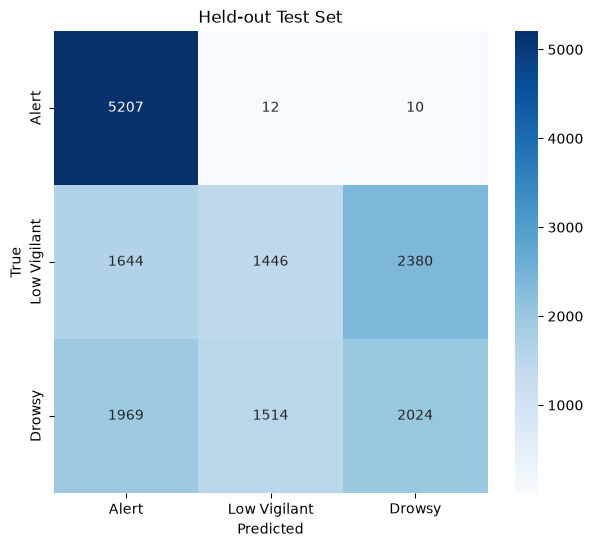

Accuracy: 0.53541898062446
Macro F1: 0.49728631936682727


In [61]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    yticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ]
)

plt.title("Held-out Test Set")
plt.ylabel("True")
plt.xlabel("Predicted")

plt.savefig(
    PROJECT_ROOT / "heldout_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Accuracy:",
      accuracy_score(all_labels, all_preds))
print("Macro F1:",
      f1_score(all_labels, all_preds, average="macro"))

In [46]:
from sklearn.metrics import f1_score, accuracy_score

results = []

start = 0

for s in PHASE9_SUBJECTS:
    n = len(test_df[test_df["subject"] == s])

    y_true = np.array(all_labels)[start:start+n]
    y_pred = np.array(all_preds)[start:start+n]

    results.append({
        "Subject": s,
        "Windows": n,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    })

    start += n

pd.DataFrame(results)

,Subject,Windows,Accuracy,Macro_F1
0,01,1736,0.623848,0.498656
1,06,1388,0.444524,0.263338
2,11,1822,0.732162,0.727017
3,16,1594,0.319322,0.254365
4,21,1723,0.412652,0.316004
5,26,2106,0.558405,0.513167
6,31,1845,0.360976,0.216855
7,36,1789,0.667412,0.557933
8,41,2203,0.491602,0.446749


In [63]:
sample = test_df.iloc[0]["embedding_path"]
print(sample)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\normalized_embeddings\01\alert.npy


In [64]:
arr = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / "01"
    / "alert.npy"
)

print(arr.mean())
print(arr.std())

-3.0615548e-09
0.8267974


In [65]:
for s in PHASE9_SUBJECTS:
    subject_df = test_df[
        test_df["subject"] == s
    ]

    print(
        s,
        len(subject_df),
        subject_df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .to_dict()
    )

01 1736 {0: 0.3421658986175115, 1: 0.3283410138248848, 2: 0.3294930875576037}
06 1388 {0: 0.4185878962536023, 1: 0.2946685878962536, 2: 0.28674351585014407}
11 1822 {0: 0.3287596048298573, 1: 0.3430296377607025, 2: 0.32821075740944017}
16 1594 {0: 0.2791718946047679, 1: 0.3607277289836888, 2: 0.3601003764115433}
21 1723 {0: 0.334881021474173, 1: 0.3325594892629135, 2: 0.3325594892629135}
26 2106 {0: 0.2792022792022792, 1: 0.4050332383665717, 2: 0.3157644824311491}
31 1845 {0: 0.35284552845528455, 1: 0.31273712737127374, 2: 0.3344173441734417}
36 1789 {0: 0.3325880380100615, 1: 0.33426495248742316, 2: 0.33314700950251536}
41 2203 {0: 0.27190195188379485, 1: 0.31320926009986383, 2: 0.4148887880163413}


In [66]:
subject_results = []

for s in PHASE9_SUBJECTS:
    mask = (
        test_df["subject"]
        .reset_index(drop=True)
        == s
    )

    idx = np.where(mask)[0]

    y_true = np.array(all_labels)[idx]
    y_pred = np.array(all_preds)[idx]

    subject_results.append({
        "Subject": s,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    })

subject_results = pd.DataFrame(subject_results)
print(subject_results)

  Subject  Accuracy  Macro_F1
0      01  0.636521  0.522838
1      06  0.447406  0.263636
2      11  0.628979  0.591265
3      16  0.286073  0.202330
4      21  0.363900  0.266790
5      26  0.472934  0.472527
6      31  0.682927  0.653745
7      36  0.692007  0.639991
8      41  0.557422  0.540709


In [67]:
for s in ["01", "06", "11", "16", "21"]:
    for state in ["alert", "low_vigilant", "drowsy"]:
        arr = np.load(
            PROJECT_ROOT
            / "processed"
            / "UTA"
            / "normalized_embeddings"
            / s
            / f"{state}.npy"
        )

        print(
            s,
            state,
            f"mean={arr.mean():.4f}",
            f"std={arr.std():.4f}",
            f"min={arr.min():.4f}",
            f"max={arr.max():.4f}"
        )

01 alert mean=-0.0000 std=0.8268 min=-3.3497 max=24.9402
01 low_vigilant mean=0.2690 std=94.4418 min=-4.2040 max=48844.1602
01 drowsy mean=0.6031 std=117.9985 min=-4.2040 max=63803.8906
06 alert mean=-0.0000 std=0.9228 min=-1.5986 max=24.6780
06 low_vigilant mean=0.0263 std=2.3176 min=-1.5986 max=745.6970
06 drowsy mean=-0.0473 std=0.8772 min=-1.5986 max=35.3149
11 alert mean=-0.0000 std=0.8443 min=-3.0173 max=25.0402
11 low_vigilant mean=1.7315 std=20.8395 min=-3.0173 max=2233.3662
11 drowsy mean=0.5679 std=9.4608 min=-3.0173 max=1492.0425
16 alert mean=-0.0000 std=0.8992 min=-2.8470 max=21.7487
16 low_vigilant mean=0.9211 std=13.5733 min=-3.4790 max=2795.8777
16 drowsy mean=0.0710 std=7.2984 min=-3.4790 max=1113.9960
21 alert mean=0.0000 std=0.8872 min=-3.1161 max=24.5968
21 low_vigilant mean=0.6247 std=23.2043 min=-3.1161 max=2621.2744
21 drowsy mean=0.1591 std=11.9958 min=-3.1161 max=2251.7351


In [68]:
std = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / "01"
    / "std.npy"
)

print(std.min())
print(np.percentile(std, [1, 5, 10]))
print((std < 1e-6).sum())
print((std < 1e-4).sum())

1.5967737e-05
[0.00404516 0.01149321 0.02827869]
0
1


In [69]:
subject = "01"

std = np.load(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "normalized_embeddings"
    / subject
    / "std.npy"
)

print("10 smallest std values:")
print(np.sort(std)[:10])

print("\nIndices of smallest std values:")
print(np.argsort(std)[:10])

10 smallest std values:
[1.5967737e-05 1.6151863e-04 2.3280808e-03 2.9239326e-03 3.6885231e-03
 4.0101367e-03 4.3285433e-03 4.6933969e-03 4.9899924e-03 5.4124040e-03]

Indices of smallest std values:
[340 450  34 157   5 255 493 137 206 416]


In [70]:
idx = np.argsort(std)[:10]

for state in ["alert", "low_vigilant", "drowsy"]:
    arr = np.load(
        PROJECT_ROOT
        / "processed"
        / "UTA"
        / "normalized_embeddings"
        / subject
        / f"{state}.npy"
    )

    print(f"\n{state}")
    print(arr[:, idx].max(axis=0))


alert
[24.939917 24.939976 24.940052 18.90645  13.310233 24.939909 20.248152
 23.757973 24.939926 24.939999]

low_vigilant
[ 4.8844160e+04  1.7017369e+02  3.7666573e+01  1.3943427e+02
  3.4140247e+01  1.0530546e+01  4.0047188e+01  3.7034946e+02
 -4.0096346e-02  8.8509842e+01]

drowsy
[ 6.3803891e+04  1.3497852e+02  3.7900095e+02  8.4382505e+00
  4.2349812e+01  2.5101338e+02  1.3489459e+02  5.7195715e+02
 -4.0096346e-02  5.4163540e+01]
